# Tutorial — Stroboscopic Spin–Motion Physics

A visitor-friendly walk-through of the physical setup behind the Hasse 2024 stroboscopic scheme. Four sections:

1. **Pulse train** in time and frequency domain → comb of Fourier teeth at $k\cdot\omega_m$.
2. **Spin–motion dynamics** → Bloch-vector trajectory and Wigner snapshots of the motional state.
3. **Semi-classical analogies** → the strobe-wheel picture, FM-sideband dictionary, and the strong-vs-weak binding distinction that separates this from a naive Doppler shift.
4. **Tie-back** to the $(\vartheta_0, \delta)$ Fig 6 scan documented in the 2026-04-20 logbook.

All numerics use the `scripts/stroboscopic` package (restructured v1.0.0). Most cells run in well under a second; the §4 tie-back takes a few seconds.


## §0 Setup

Imports and a small local helper module for Bloch and Wigner plots.

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import qutip

REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(REPO, 'scripts'))

from stroboscopic import HilbertSpace, operators as ops, hamiltonian as ham
from stroboscopic import propagators as prop, sequences

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})


In [2]:
# ── Helpers ──────────────────────────────────────────────────
def plot_bloch(ax, vecs, colors=None, labels=None, title=None):
    '''y-z projection of Bloch vectors (adequate for MW-equator states).'''
    ax.add_patch(Circle((0, 0), 1.0, fill=False, lw=1.0))
    ax.plot([-1.05, 1.05], [0, 0], color='gray', lw=0.4)
    ax.plot([0, 0], [-1.05, 1.05], color='gray', lw=0.4)
    colors = colors or ['C0'] * len(vecs)
    labels = labels or [None] * len(vecs)
    for v, c, lbl in zip(vecs, colors, labels):
        _, vy, vz = v
        ax.arrow(0, 0, vy, vz, head_width=0.05, length_includes_head=True,
                 color=c, label=lbl)
    ax.set_aspect('equal'); ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel(r'$\langle\sigma_y\rangle$')
    ax.set_ylabel(r'$\langle\sigma_z\rangle$')
    ax.grid(alpha=0.15)
    if title: ax.set_title(title, fontsize=9)
    if any(labels): ax.legend(fontsize=7, loc='upper right')


def motional_rho(psi, nmax):
    '''Trace out spin → reduced motional density matrix as qutip.Qobj.'''
    down = np.asarray(psi[:nmax]); up = np.asarray(psi[nmax:])
    rho_m = np.outer(down, down.conj()) + np.outer(up, up.conj())
    return qutip.Qobj(rho_m)


def plot_wigner(ax, psi, nmax, grid=None, title=None, vmax=None):
    rho = motional_rho(psi, nmax)
    if grid is None:
        grid = np.linspace(-7.5, 7.5, 161)
    W = qutip.wigner(rho, grid, grid, g=2)
    if vmax is None:
        vmax = float(np.max(np.abs(W)))
    ax.imshow(W, extent=[grid[0], grid[-1], grid[0], grid[-1]], origin='lower',
              cmap='RdBu_r', vmin=-vmax, vmax=+vmax, aspect='equal')
    ax.set_xlabel(r'Re $\alpha$'); ax.set_ylabel(r'Im $\alpha$')
    ax.grid(alpha=0.15)
    if title: ax.set_title(title, fontsize=9)


def observables(psi, nmax):
    hs_loc = HilbertSpace(n_spins=1, mode_cutoffs=(nmax,))
    o = hs_loc.observables(psi)
    return o['sigma_x'], o['sigma_y'], o['sigma_z']

## §1 Pulse train — time and frequency domain

### §1.1 A train of N identical kicks

The AC drive is a sequence of $N$ square pulses of duration $\delta t$, repeated with period $T_m = 2\pi/\omega_m$. For the Hasse scan we use $N=30$, $\delta t/T_m = 0.13$, and $\omega_m = 2 \pi 1.3$ MHz.

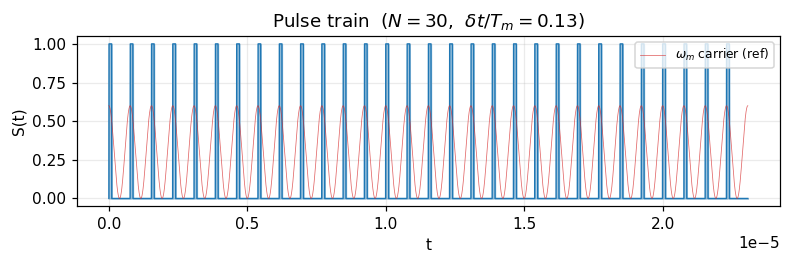

In [3]:
omega_m = 1.3 *2*np.pi *1e6
T_m = 2 * np.pi / omega_m
dt = 0.13 * T_m
N = 30

t = np.linspace(0, N * T_m, 4000)
S = np.zeros_like(t)
for k in range(N):
    S[(t > k * T_m) & (t <= k * T_m + dt)] = 1.0

fig, ax = plt.subplots(figsize=(7.2, 2.5))
ax.plot(t, S, 'C0', lw=0.9)
ax.fill_between(t, 0, S, alpha=0.35, color='C0')
ax.plot(t, 0.3 * (1 + np.cos(omega_m * t)), 'C3', lw=0.5, alpha=0.7,
        label=r'$\omega_m$ carrier (ref)')
ax.set_xlabel('t'); ax.set_ylabel('S(t)')
ax.set_title(fr'Pulse train  ($N={N}$,  $\delta t/T_m={dt/T_m:.2f}$)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()


### §1.2 Fourier content — comb under a sinc envelope

$\hat S(\omega)$ factorises into

$$\hat S(\omega) \;=\; \underbrace{\mathrm{sinc}(\omega\,\delta t/2)}_{\text{single-pulse envelope}}\;\times\;\underbrace{\frac{\sin(N\,\omega\,T_m/2)}{\sin(\omega\,T_m/2)}}_{\text{comb of }N\text{-pulse lines}}.$$

The envelope is smooth; the comb has peaks at $\omega=k\omega_m$ with width $\sim 1/(N\,T_m)$. This is the same structure visible in the 2026-04-20 logbook's $|C|(\vartheta_0, \delta)$ map: narrow bright bands at integer $\delta/\omega_m$, everything off-tooth preserved.

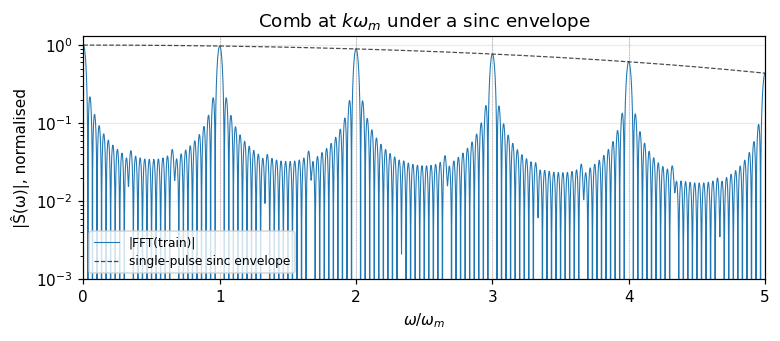

In [4]:
pad = 20
t_pad = np.linspace(0, pad * N * T_m, pad * 4000, endpoint=False)
S_pad = np.zeros_like(t_pad)
for k in range(N):
    S_pad[(t_pad > k * T_m) & (t_pad <= k * T_m + dt)] = 1.0
Smag = np.abs(np.fft.rfft(S_pad))
freq = np.fft.rfftfreq(len(t_pad), d=t_pad[1] - t_pad[0])
omega = 2 * np.pi * freq

env = np.abs(np.sinc((omega * dt) / (2 * np.pi))) #np.sinc(x) = sin(np.pi*x)/(np.pi*x)

fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.plot(omega / omega_m, Smag / Smag.max(), 'C0', lw=0.7, label='|FFT(train)|')
ax.plot(omega / omega_m, env / env.max(), 'k--', lw=0.8, alpha=0.7,
        label=r'single-pulse sinc envelope')
for k in [1, 2, 3, 4]:
    ax.axvline(k, color='gray', lw=0.4, ls=':')
ax.set_yscale('log'); ax.set_ylim(1e-3, 1.3)
ax.set_xlim(0, 5)
ax.set_xlabel(r'$\omega / \omega_m$'); ax.set_ylabel('|Ŝ(ω)|, normalised')
ax.set_title('Comb at $k\\omega_m$ under a sinc envelope')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### §1.3 Tooth narrows like 1/N

As we add more pulses, each comb tooth sharpens: HWHM in $\delta/\omega_m$ scales as $1/N$. In the 2026-04-20 baseline ($N=30$) the expected HWHM is $\approx 0.033$ — this is the physical origin of the narrow bands in $|C|(\vartheta_0, \delta)$.

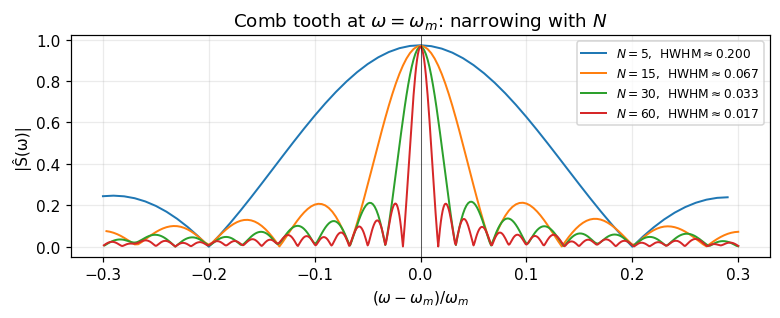

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.0))
for N_try, col in zip([5, 15, 30, 60], ['C0', 'C1', 'C2', 'C3']):
    t_ = np.linspace(0, N_try * T_m * pad, pad * max(N_try, 30) * 40, endpoint=False)
    S_ = np.zeros_like(t_)
    for k in range(N_try):
        S_[(t_ > k * T_m) & (t_ <= k * T_m + dt)] = 1.0
    f_ = np.fft.rfftfreq(len(t_), d=t_[1] - t_[0])
    om_ = 2 * np.pi * f_
    Sm = np.abs(np.fft.rfft(S_)); Sm = Sm / Sm.max()
    near = np.abs(om_ / omega_m - 1) < 0.3
    ax.plot((om_ / omega_m)[near] - 1, Sm[near], color=col, lw=1.3,
            label=fr'$N={N_try}$,  HWHM$\approx{1/N_try:.3f}$')
ax.axvline(0, color='k', lw=0.4)
ax.set_xlabel(r'$(\omega - \omega_m)/\omega_m$')
ax.set_ylabel('|Ŝ(ω)|')
ax.set_title(r'Comb tooth at $\omega=\omega_m$: narrowing with $N$')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## §2 Spin–motion dynamics

The ion is described by a joint state $|\psi\rangle = |\text{spin}\rangle \otimes |\text{motion}\rangle$. Motion is a coherent state $|\alpha\rangle$; spin is $|\!\downarrow\rangle$ until the MW $\pi/2$ pulse places it on $+\hat y$ of the Bloch equator.

Each per-pulse Hamiltonian is
$$H_\text{pulse} = \frac{\delta}{2}\sigma_z + \omega_m a^\dagger a + \frac{\Omega}{2}\left(e^{i\varphi}\,C\,\sigma_- + e^{-i\varphi}\,C^\dagger\,\sigma_+\right),\qquad C = e^{i\eta(a+a^\dagger)}.$$

$C$ is the Lamb-Dicke displacement operator: it couples the spin flip to a position-conditioned phase. The Debye–Waller factor $e^{-\eta^2/2}$ is its on-diagonal value.

### §2.1 Initial state — Bloch + Wigner side by side

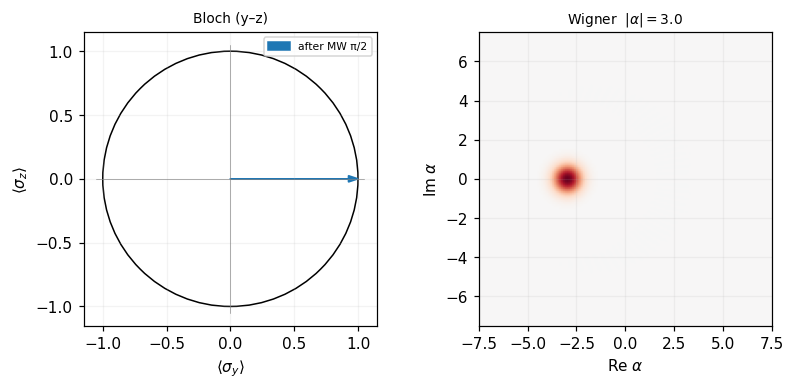

In [9]:
alpha_abs = 3.0
nmax = 60
hs = HilbertSpace(n_spins=1, mode_cutoffs=(nmax,))

psi_coh = hs.prepare_state(spin={'theta_deg': 0.0, 'phi_deg': 0.0},
                           modes=[{'alpha': alpha_abs, 'alpha_phase_deg': 0.0}])
psi_mw = hs.apply_mw_pi2(psi_coh, mw_phase_deg=0.0)

fig, (ax_b, ax_w) = plt.subplots(1, 2, figsize=(7.6, 3.6),
                                  gridspec_kw={'width_ratios': [1, 1.15]})
plot_bloch(ax_b, [observables(psi_mw, nmax)], labels=['after MW π/2'],
           title='Bloch (y–z)')
plot_wigner(ax_w, psi_mw, nmax, title=fr'Wigner  $|\alpha|={alpha_abs}$')
plt.tight_layout(); plt.show()

### §2.2 A single pulse — displacement-dressed rotation

Expanding $C \approx 1 + i\eta(a+a^\dagger) + \mathcal O(\eta^2)$, one pulse acts as an $X$-rotation whose angle depends on position (via $a+a^\dagger$). The spin tilts and the Wigner blob acquires a small splitting between the two spin components — this is the seed of the $\vartheta_0$-structure seen in Hasse Fig 6a.

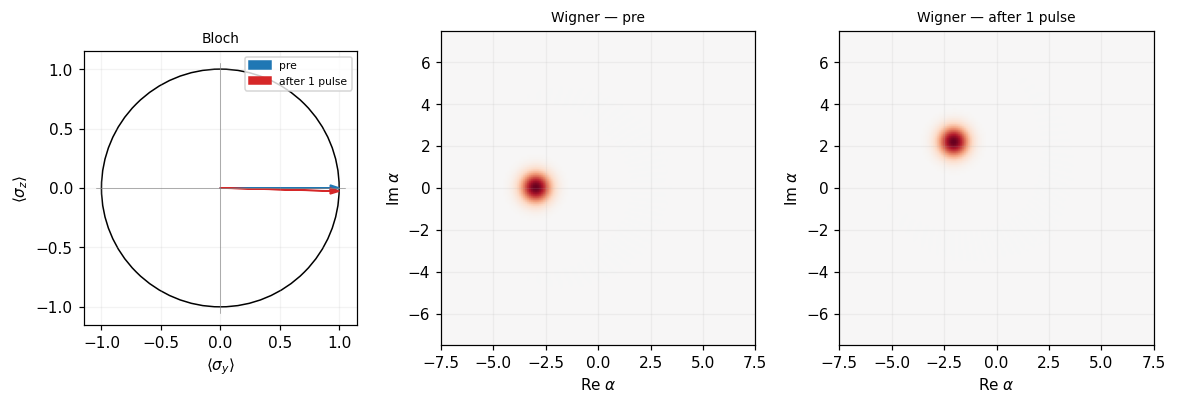

In [10]:
eta = 0.397
omega_eff = np.pi / (2 * N * dt)          # π/2 budget over N pulses
omega_r = omega_eff / np.exp(-eta ** 2 / 2)

C = ops.coupling(eta, nmax); Cdag = C.conj().T

def build_train(delta, n_pulses):
    H = ham.build_pulse_hamiltonian(eta, omega_r, delta, nmax, C, Cdag,
                                     ac_phase_rad=0.0, omega_m=omega_m,
                                     intra_pulse_motion=True)
    Up = prop.build_U_pulse(H, dt)
    Ug = prop.build_U_gap(nmax, omega_m, T_m - dt, delta=delta)
    return sequences.StroboTrain(U_pulse=Up, U_gap_diag=Ug, n_pulses=n_pulses)

train_on = build_train(delta=0.0, n_pulses=N)
psi_1 = train_on.U_pulse @ psi_mw

fig, axs = plt.subplots(1, 3, figsize=(10.8, 3.6),
                        gridspec_kw={'width_ratios': [1, 1.15, 1.15]})
plot_bloch(axs[0], [observables(psi_mw, nmax), observables(psi_1, nmax)],
           colors=['C0', 'C3'], labels=['pre', 'after 1 pulse'], title='Bloch')
plot_wigner(axs[1], psi_mw, nmax, title='Wigner — pre')
plot_wigner(axs[2], psi_1, nmax, title='Wigner — after 1 pulse')
plt.tight_layout(); plt.show()


### §2.3 Full N-pulse train — snapshots

Running the $N=30$ on-resonance train and sampling at $k=0, N/4, N/2, 3N/4, N$. The Bloch vector swings from $+\hat y$ towards $\pm\hat z$ and the Wigner blob elongates and distorts — this is what the $\langle\sigma_z\rangle(\vartheta_0, 0)$ diamond and the $\delta\langle n\rangle$ back-action of Fig 6b are made of.

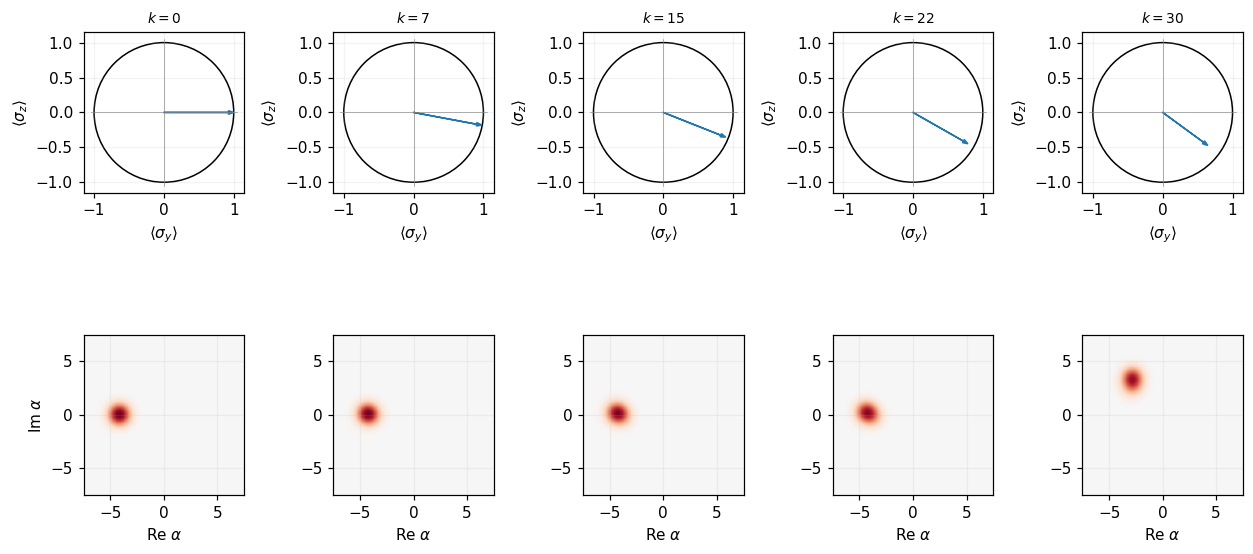

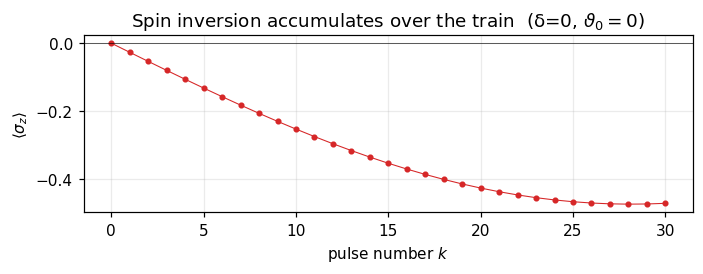

In [11]:
_, history = train_on.evolve(psi_mw, record_steps=True)
snaps = [0, N // 4, N // 2, 3 * N // 4, N]

fig, axs = plt.subplots(2, len(snaps), figsize=(2.3 * len(snaps), 5.8),
                        gridspec_kw={'height_ratios': [1, 1.25]})
# Common Wigner vmax for visual comparison
wmax = 0.0
ws = []
grid = np.linspace(-7.5, 7.5, 121)
for k in snaps:
    W = qutip.wigner(motional_rho(history[k], nmax), grid, grid)
    ws.append(W)
    wmax = max(wmax, float(np.max(np.abs(W))))
for col, k in enumerate(snaps):
    plot_bloch(axs[0, col], [observables(history[k], nmax)], title=fr'$k={k}$')
    axs[1, col].imshow(ws[col], extent=[grid[0], grid[-1], grid[0], grid[-1]],
                       origin='lower', cmap='RdBu_r', vmin=-wmax, vmax=+wmax,
                       aspect='equal')
    axs[1, col].set_xlabel(r'Re $\alpha$')
    if col == 0: axs[1, col].set_ylabel(r'Im $\alpha$')
    axs[1, col].grid(alpha=0.15)
plt.tight_layout(); plt.show()

# σ_z trajectory
szs = [observables(p, nmax)[2] for p in history]
fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.plot(range(len(history)), szs, 'o-', lw=0.7, ms=3, color='C3')
ax.axhline(0, color='k', lw=0.4)
ax.set_xlabel('pulse number $k$'); ax.set_ylabel(r'$\langle\sigma_z\rangle$')
ax.set_title(r'Spin inversion accumulates over the train  (δ=0, $\vartheta_0=0$)')
plt.tight_layout(); plt.show()

### §2.4 On-resonance vs off-resonance

At $\delta = 0$ the pulses all add up: the spin flips and the motion is kicked. At $\delta = 0.5\,\omega_m$ (half-way between teeth), successive pulses arrive at drifting phases — the contributions cancel and the state barely moves. This is the $|C|\approx 1$ "preserved coherence" background of the $|C|$ map.

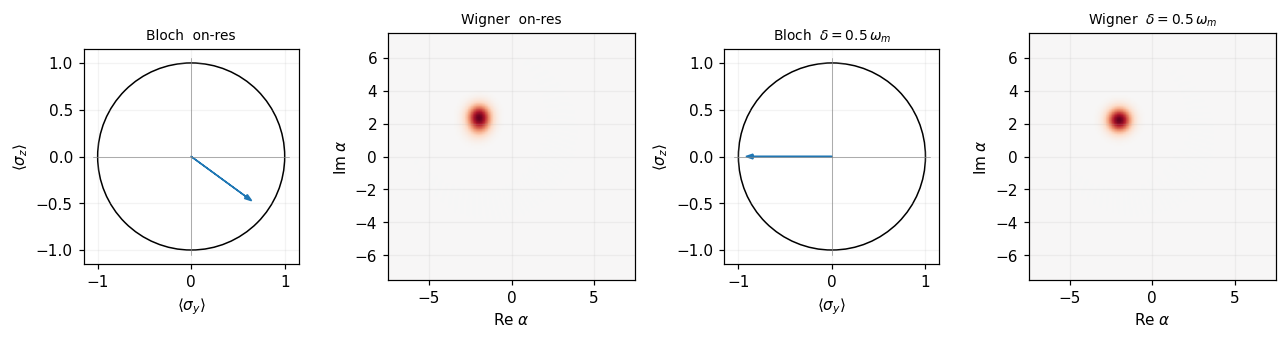

In [12]:
train_off = build_train(delta=0.5 * omega_m, n_pulses=N)
psi_off_final = train_off.evolve(psi_mw)

fig, axs = plt.subplots(1, 4, figsize=(11.8, 3.2),
                        gridspec_kw={'width_ratios': [1, 1.15, 1, 1.15]})
plot_bloch(axs[0], [observables(history[-1], nmax)], title=r'Bloch  on-res')
plot_wigner(axs[1], history[-1], nmax, title='Wigner  on-res')
plot_bloch(axs[2], [observables(psi_off_final, nmax)],
           title=r'Bloch  $\delta=0.5\,\omega_m$')
plot_wigner(axs[3], psi_off_final, nmax,
            title=r'Wigner  $\delta=0.5\,\omega_m$')
plt.tight_layout(); plt.show()


### §2.5 Carrier and sideband coupling strengths vs $|\alpha|$

So far we've looked at the spin–motion dynamics at our working point $|\alpha|=3$. How does the strength of each motional sideband depend on $|\alpha|$?

Expand the Lamb–Dicke displacement $C_I(t) = D\!\bigl(i\eta\,e^{i\omega_m t}\bigr)$ in the interaction picture and take its coherent-state expectation value:

$$\langle\alpha|C_I(t)|\alpha\rangle \;=\; e^{-\eta^2/2}\,\exp\!\Bigl[\,2i\eta|\alpha|\cos(\omega_m t - \vartheta_0)\Bigr] \;=\; e^{-\eta^2/2}\sum_{-k}^{\infty} i^k\,J_k\!\bigl(2\eta|\alpha|\bigr)\,e^{-ik\vartheta_0}\,e^{ik\omega_m t}$$

(Jacobi–Anger identity on the right). The effective Rabi rate on the $k$-th motional sideband — the spin transition at $\omega_{\rm MW} + k\,\omega_m$ — is therefore

$$\frac{\Omega_k}{\Omega} \;=\; e^{-\eta^2/2}\,\bigl|J_k(2\eta|\alpha|)\bigr|.$$

Here $$\beta\coloneqq2\eta|\alpha$$ is also known as the phase-modulation index. $\beta$ is furthermore defined as 
$$\beta=\vec{k}_\text{eff} x_\text{max} = \frac{\vec{k}_\text{eff}  v_\text{max} }{\omega_\text{m}} = \frac{\Delta\omega_\text{D}}{\omega_\text{m}},$$
which can be a useful tool to describe the motion of the coherently displaced ion.

Physically: a larger coherent amplitude spreads the motional wavepacket over more Lamb–Dicke wavelengths, so more spatial Fourier components contribute and carrier weight drains into progressively higher sidebands. We plot this Bessel fan for $|\alpha|\in\{0, 1, 3, 4.5\}$:

- **$|\alpha|=0$** (motional ground state): all coupling on the carrier at the Debye–Waller value $e^{-\eta^2/2}\approx 0.924$; no sidebands.
- **$|\alpha|=1$**: carrier still dominant, first sideband beginning to emerge.
- **$|\alpha|=3$** (our working point): $2\eta|\alpha|=2.38$ sits essentially on the first zero of $J_0$ at $2.405$, so the *carrier is accidentally extinguished*; first two sidebands carry most of the coupling.
- **$|\alpha|=4.5$**: weight redistributed further; second and third sidebands dominate.

This motional-state factor multiplies the pulse-duration sinc envelope from §3.2 — both shape the effective k-th sideband Rabi rate.

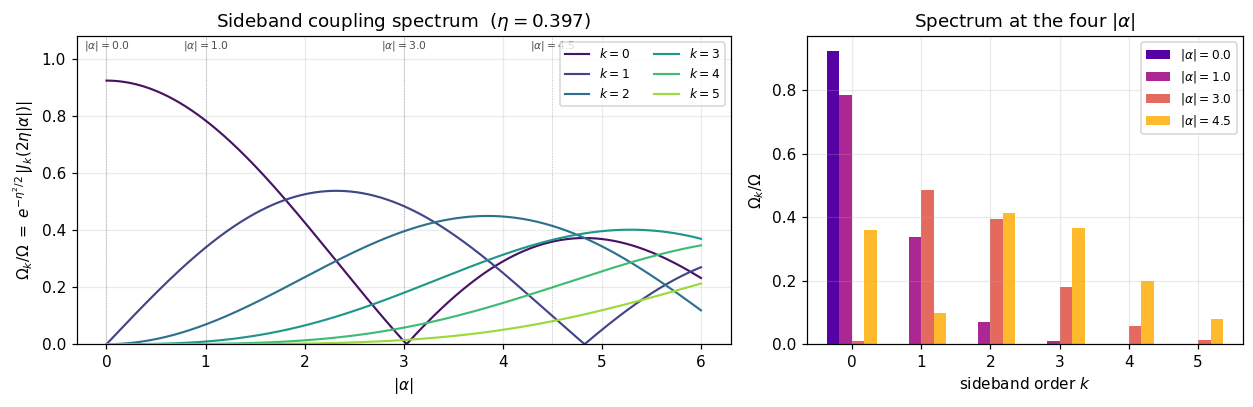

η = 0.397, Debye–Waller e^(-η²/2) = 0.9242

Ω_k / Ω  for each |α|:
  |α|  |  k=0    k=1    k=2    k=3    k=4    k=5 
  -----------------------------------------------
  0.0  | 0.9242  0.0000  0.0000  0.0000  0.0000  0.0000
  1.0  | 0.7842  0.3388  0.0691  0.0093  0.0009  0.0001
  3.0  | 0.0110  0.4843  0.3956  0.1801  0.0579  0.0145
  4.5  | 0.3596  0.0987  0.4148  0.3657  0.1993  0.0805


In [14]:
from scipy.special import jv

alpha_show = [0.0, 1.0, 3.0, 4.5]
alpha_cont = np.linspace(0, 6, 401)
k_max = 5
debye_waller = np.exp(-eta**2 / 2)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 3.8),
                                gridspec_kw={'width_ratios': [1.5, 1]})

colors = plt.cm.viridis(np.linspace(0.05, 0.85, k_max + 1))
for k in range(k_max + 1):
    axL.plot(alpha_cont, debye_waller * np.abs(jv(k, 2 * eta * alpha_cont)),
             color=colors[k], lw=1.4, label=fr'$k={k}$')
for a_pt in alpha_show:
    axL.axvline(a_pt, color='k', lw=0.4, alpha=0.45, ls=':')
    axL.text(a_pt, 1.02, fr'$|\alpha|={a_pt}$', fontsize=7,
             ha='center', va='bottom', color='k', alpha=0.7)
axL.set_xlabel(r'$|\alpha|$')
axL.set_ylabel(r'$\Omega_k / \Omega \;=\; e^{-\eta^2/2}\,|J_k(2\eta|\alpha|)|$')
axL.set_title(fr'Sideband coupling spectrum  ($\eta={eta:.3f}$)')
axL.set_ylim(0, 1.08)
axL.legend(fontsize=8, ncol=2, loc='upper right')
axL.grid(alpha=0.25)

x = np.arange(k_max + 1)
width = 0.18
bar_colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(alpha_show)))
for i, a_pt in enumerate(alpha_show):
    strengths = debye_waller * np.abs(jv(x, 2 * eta * a_pt))
    axR.bar(x + (i - (len(alpha_show) - 1) / 2) * width, strengths, width,
            color=bar_colors[i], label=fr'$|\alpha|={a_pt}$')
axR.set_xlabel('sideband order $k$')
axR.set_ylabel(r'$\Omega_k / \Omega$')
axR.set_xticks(x)
axR.set_title(r'Spectrum at the four $|\alpha|$')
axR.legend(fontsize=8)
axR.grid(alpha=0.25, axis='y')

plt.tight_layout(); plt.show()

print(f'η = {eta:.3f}, Debye–Waller e^(-η²/2) = {debye_waller:.4f}')
print(f'\nΩ_k / Ω  for each |α|:')
header = '  |α|  | ' + '  '.join(f' k={k} ' for k in range(k_max + 1))
print(header)
print('  ' + '-' * (len(header) - 2))
for a_pt in alpha_show:
    strengths = debye_waller * np.abs(jv(np.arange(k_max + 1), 2 * eta * a_pt))
    print(f'  {a_pt:>3.1f}  | ' + '  '.join(f'{s:.4f}' for s in strengths))

## §3 Semi-classical analogies

### §3.1 Strobe wheel

Think of the motional coordinate as a phasor rotating at $\omega_m$. Each pulse samples that phasor once per $T_m$. If the train period matches the motion (δ=0), every pulse sees the phasor at the same phase and the kicks add coherently. If δ is offset, each pulse sees a slightly rotated phasor — the sum walks around and eventually cancels.

The Argand plots below show $\Sigma_k e^{i\delta k T_m}$ for three detunings. The length of the red endpoint is the "effective" pulse-train amplitude at that detuning.

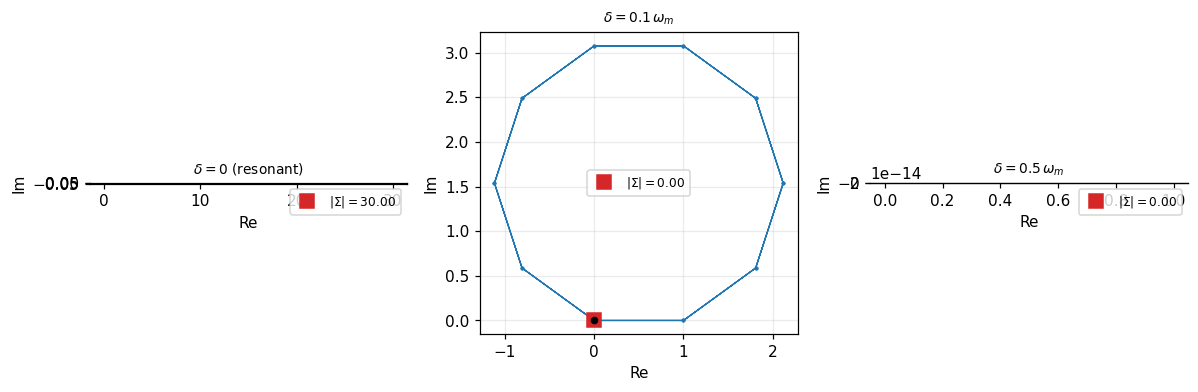

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, d_rel, title in zip(axes, [0.0, 0.1, 0.5],
        [r'$\delta=0$ (resonant)', r'$\delta=0.1\,\omega_m$', r'$\delta=0.5\,\omega_m$']):
    delta = d_rel * omega_m
    k = np.arange(N)
    phi = delta * k * T_m
    xs = np.cos(phi); ys = np.sin(phi)
    cumx = np.concatenate(([0], np.cumsum(xs)))
    cumy = np.concatenate(([0], np.cumsum(ys)))
    ax.plot(cumx, cumy, '-', lw=0.8, color='C0')
    ax.plot(cumx, cumy, '.', ms=3, color='C0')
    ax.plot(cumx[-1], cumy[-1], 's', color='C3', ms=9,
            label=fr'$|\Sigma|={np.hypot(cumx[-1], cumy[-1]):.2f}$')
    ax.plot(0, 0, 'ko', ms=4)
    ax.set_title(title, fontsize=9); ax.set_aspect('equal')
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.legend(fontsize=8, loc='best')
plt.tight_layout(); plt.show()


### §3.2 FM-sideband dictionary

The stroboscopic train in the interaction picture is an FM modulator: the carrier is the spin transition at $\omega_\text{MW}$, the modulation is the pulse-train envelope at $\omega_m$. The spectrum is a **carrier + symmetric sidebands** at $\pm k\,\omega_m$, and the $k$-th sideband amplitude follows the single-pulse sinc, exactly as in §1.2.

For a square envelope: $A_k \propto \mathrm{sinc}(k\,\omega_m\,\delta t/2)$.

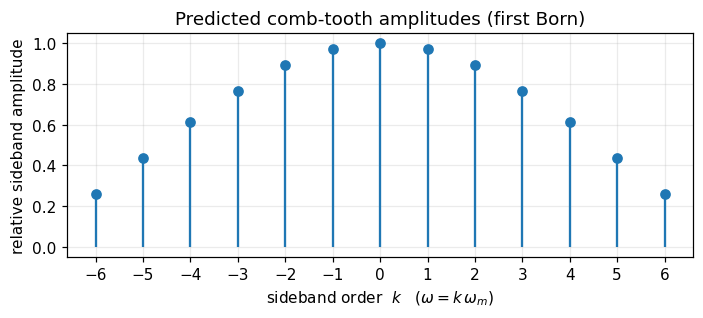

In [18]:
ks = np.arange(-6, 7)
ticks = ks * omega_m
amps = np.abs(np.sinc(ticks * dt / (2 * np.pi))) #* (dt / T_m)

fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.stem(ks, amps, basefmt=' ')
ax.set_xlabel(r'sideband order  $k$   ($\omega = k\,\omega_m$)')
ax.set_ylabel('relative sideband amplitude')
ax.set_title('Predicted comb-tooth amplitudes (first Born)')
ax.set_xticks(ks)
plt.tight_layout(); plt.show()


### §3.3 Strong vs weak binding — why this is not a naive Doppler shift

Everything above relied on the motion being **resolved**: the spectral width of the train must fit inside one mode spacing $\omega_m$. Two numbers set this:

- **Tooth width** in units of $\omega_m$: $1/N$. Need $1/N \ll 1$.
- **Single-pulse bandwidth**: $1/\delta t$ in angular units, or $\omega_m \delta t = 2\pi \cdot (\delta t/T_m)$ as the relevant phase per mode period. Need $\delta t \ll T_m$.

For our parameters ($N=30$, $\delta t/T_m = 0.13$) both hold with room to spare. This is the **strong-binding** / **resolved-sideband** limit: the spin sees a *discrete* comb of mechanical sidebands at $k\,\omega_m$ and we can do phase-coherent sideband operations.

Contrast this with a **weak-binding** / **unresolved-sideband** limit — a single short pulse, or $\Omega \gtrsim \omega_m$, or $N$ so small that teeth overlap. Then the spin sees a *continuum* of frequencies under one broad envelope. Classically this is the naive Doppler picture: a coherent state with amplitude $|\alpha|$ has velocity $v(t) = \eta|\alpha|\omega_m \cos(\omega_m t + \vartheta_0)$, so the carrier is instantaneously Doppler-shifted across a range $\pm \eta|\alpha|\,\omega_m$. You'd see a broad Doppler profile, not a comb.

**Why this matters for Fig 6.** The naive Doppler picture is $\vartheta_0$-symmetric: a coherent state's velocity distribution is rotationally invariant. It cannot produce the $\vartheta_0$-dependent diamond in $\langle\sigma_z\rangle$ — that pattern lives inside a single tooth of the resolved comb and is an intrinsically **phase-resolved** quantum feature of strong binding.

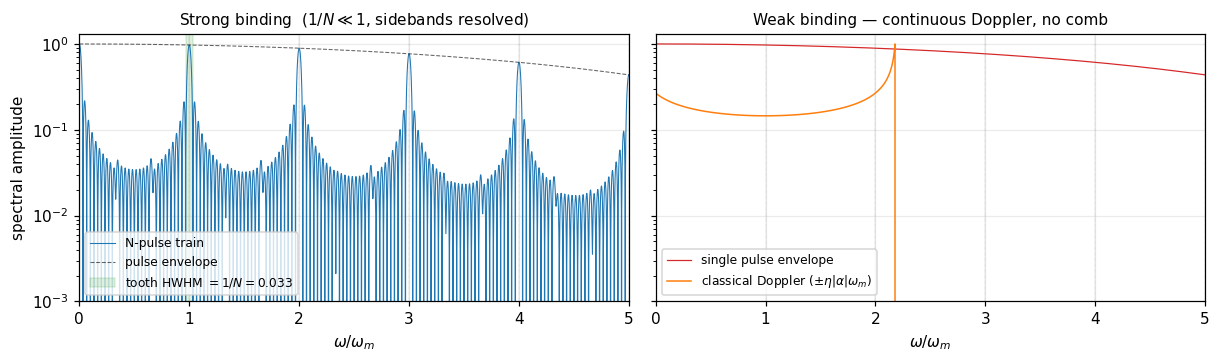

Resolution check for our parameters:
  tooth width 1/N         = 0.0333 (need << 1)
  pulse bandwidth δt/T_m  = 0.1300 (need << 1)
  Doppler halfwidth η|α|  = 1.191 ω_m
  → strong-binding condition HOLDS.


In [19]:
# Two-panel spectrum comparison: resolved comb vs single-pulse / Doppler envelope.
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.4), sharey=True)

# (a) Strong binding — the comb from §1
ax1 = axes[0]
ax1.plot(omega / omega_m, Smag / Smag.max(), 'C0', lw=0.7, label='N-pulse train')
ax1.plot(omega / omega_m, env / env.max(), 'k--', lw=0.7, alpha=0.6, label='pulse envelope')
for k in [1, 2, 3, 4, 5]:
    ax1.axvline(k, color='gray', lw=0.3, ls=':')
hwhm = 1.0 / N
ax1.axvspan(1 - hwhm, 1 + hwhm, color='C2', alpha=0.15,
            label=fr'tooth HWHM $=1/N={hwhm:.3f}$')
ax1.set_xlim(0, 5)
ax1.set_yscale('log'); ax1.set_ylim(1e-3, 1.3)
ax1.set_xlabel(r'$\omega/\omega_m$'); ax1.set_ylabel('spectral amplitude')
ax1.set_title(r'Strong binding  ($1/N \ll 1$, sidebands resolved)', fontsize=10)
ax1.legend(fontsize=8, loc='lower left')

# (b) Weak binding — single short pulse + classical Doppler bump.
# Single-pulse Fourier envelope only (no comb) carries the meaningful bandwidth.
single_env = np.abs(np.sinc(omega * dt / (2 * np.pi))) * dt
single_env /= single_env.max()
# Classical Doppler profile: a point emitter oscillating at ω_m with velocity
# amplitude η|α|ω_m sweeps carrier ± η|α|ω_m instantaneously.
doppler_halfwidth = eta * alpha_abs * omega_m
carrier = 1.0 * omega_m   # any reference carrier; take ω_m itself
doppler = 1.0 / np.sqrt(
    np.clip(doppler_halfwidth**2 - (omega - carrier)**2, 1e-12, None)
)
# Truncate outside the Doppler support and normalise to peak 1.
inside = np.abs(omega - carrier) < doppler_halfwidth * 0.99
doppler[~inside] = 0.0
doppler /= max(1e-12, doppler[inside].max())

ax2 = axes[1]
ax2.plot(omega / omega_m, single_env, 'C3', lw=0.8, label='single pulse envelope')
ax2.plot(omega / omega_m, doppler, 'C1', lw=1.0,
         label=fr'classical Doppler ($\pm\eta|\alpha|\omega_m$)')
for k in [1, 2, 3, 4, 5]:
    ax2.axvline(k, color='gray', lw=0.3, ls=':')
ax2.set_xlim(0, 5)
ax2.set_yscale('log'); ax2.set_ylim(1e-3, 1.3)
ax2.set_xlabel(r'$\omega/\omega_m$')
ax2.set_title('Weak binding — continuous Doppler, no comb', fontsize=10)
ax2.legend(fontsize=8, loc='lower left')

plt.tight_layout(); plt.show()

print(f'Resolution check for our parameters:')
print(f'  tooth width 1/N         = {1/N:.4f} (need << 1)')
print(f'  pulse bandwidth δt/T_m  = {dt/T_m:.4f} (need << 1)')
print(f'  Doppler halfwidth η|α|  = {eta*alpha_abs:.3f} ω_m')
print(f'  → strong-binding condition {"HOLDS" if (1/N < 0.1 and dt/T_m < 0.3) else "is marginal"}.')


## §4 Tie-back — reproduce slices of Hasse Fig 6

### §4.1 Baseline scan at $N=30$

Small $(\vartheta_0, \delta)$ map on a $16\times41$ grid with $n_\max=60$. Runs in a few seconds and should show the same structure as `coh_theta0_det_v5.h5` / [2026-04-20-coh-theta0-det.md](../wp-hasse-reproduction/logbook/2026-04-20-coh-theta0-det.md): narrow bright $|C|$ bands at integer $\delta/\omega_m$ and the $\vartheta_0$-diamond inside each band.

  656 evolutions in 2.2 s


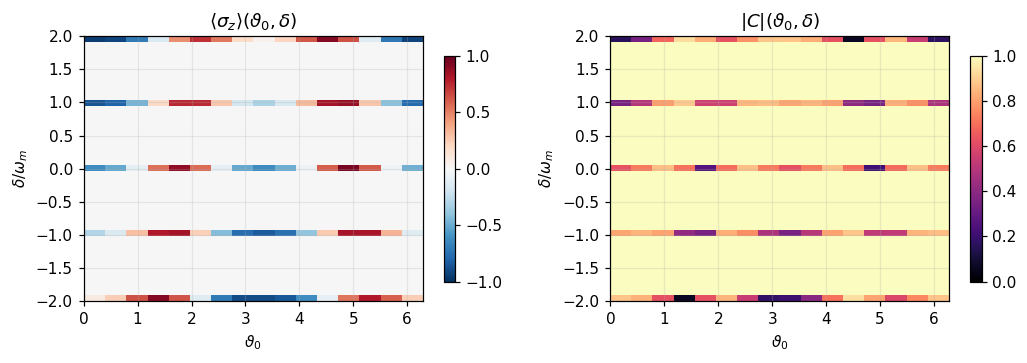

In [20]:
N_th0 = 16
det_rel_grid = np.linspace(-2.0, +2.0, 41)
theta0_grid = np.linspace(0.0, 2 * np.pi, N_th0, endpoint=False)

shift_deg = float(np.degrees(omega_m * dt / 2))
psi_starts = []
for th0 in theta0_grid:
    psi0 = hs.prepare_state(
        spin={'theta_deg': 0.0, 'phi_deg': 0.0},
        modes=[{'alpha': alpha_abs,
                'alpha_phase_deg': float(np.degrees(th0)) + shift_deg}],
    )
    psi_starts.append(hs.apply_mw_pi2(psi0, mw_phase_deg=0.0))

sz_map = np.zeros((N_th0, len(det_rel_grid)))
coh_map = np.zeros_like(sz_map)

t0 = time.time()
for j, d_rel in enumerate(det_rel_grid):
    delta_j = d_rel * omega_m
    H_j = ham.build_pulse_hamiltonian(eta, omega_r, delta_j, nmax, C, Cdag,
                                       ac_phase_rad=0.0, omega_m=omega_m,
                                       intra_pulse_motion=True)
    Up = prop.build_U_pulse(H_j, dt)
    Ug = prop.build_U_gap(nmax, omega_m, T_m - dt, delta=delta_j)
    tr = sequences.StroboTrain(U_pulse=Up, U_gap_diag=Ug, n_pulses=N)
    for i, p in enumerate(psi_starts):
        obs = hs.observables(tr.evolve(p))
        sz_map[i, j] = obs['sigma_z']
        coh_map[i, j] = np.hypot(obs['sigma_x'], obs['sigma_y'])
print(f'  {N_th0 * len(det_rel_grid)} evolutions in {time.time() - t0:.1f} s')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.6, 3.4))
im1 = a1.imshow(sz_map.T, origin='lower',
                 extent=[0, 2 * np.pi, det_rel_grid[0], det_rel_grid[-1]],
                 aspect='auto', cmap='RdBu_r', vmin=-1, vmax=+1)
a1.set_xlabel(r'$\vartheta_0$'); a1.set_ylabel(r'$\delta/\omega_m$')
a1.set_title(r'$\langle\sigma_z\rangle(\vartheta_0, \delta)$')
plt.colorbar(im1, ax=a1, shrink=0.85)

im2 = a2.imshow(coh_map.T, origin='lower',
                 extent=[0, 2 * np.pi, det_rel_grid[0], det_rel_grid[-1]],
                 aspect='auto', cmap='magma', vmin=0, vmax=1)
a2.set_xlabel(r'$\vartheta_0$'); a2.set_ylabel(r'$\delta/\omega_m$')
a2.set_title(r'$|C|(\vartheta_0, \delta)$')
plt.colorbar(im2, ax=a2, shrink=0.85)
plt.tight_layout(); plt.show()


### §4.2 Varying $N$ at fixed Rabi rate and rotation angle

How does the map change with the number of pulses? Holding the bare Rabi rate $\Omega$ and the total rotation $\Omega\,N\,\delta t = \pi/2$ both fixed, the per-pulse duration must shrink as $\delta t = \pi/(2\Omega N)$ — longer pulses for few-pulse trains, shorter pulses for many-pulse trains. We compare $N \in \{3, 7, 30\}$ at a common $\Omega$ chosen so all three trains sit inside the strong-binding regime ($\delta t < T_m$ even for $N=3$).

Expected behaviour:

- **Comb teeth have HWHM $=1/N$ in $\delta/\omega_m$**, so the bright $|C|$ bands at integer $\delta/\omega_m$ sharpen dramatically from $N=3$ to $N=30$. At $N=3$ the teeth overlap; at $N=30$ they are well-separated.
- **The $\vartheta_0$-diamond** is a phase-coherent feature inside one tooth — it only becomes clean once teeth are narrow enough not to blur into each other.
- **The on-tooth $\langle\sigma_z\rangle$ contrast** should be set by the total rotation budget ($\pi/2$), which is common to all three, so peak inversion amplitudes are comparable — what differs is the *bandwidth* over which inversion occurs.

  3 × 656 evolutions in 5.2 s


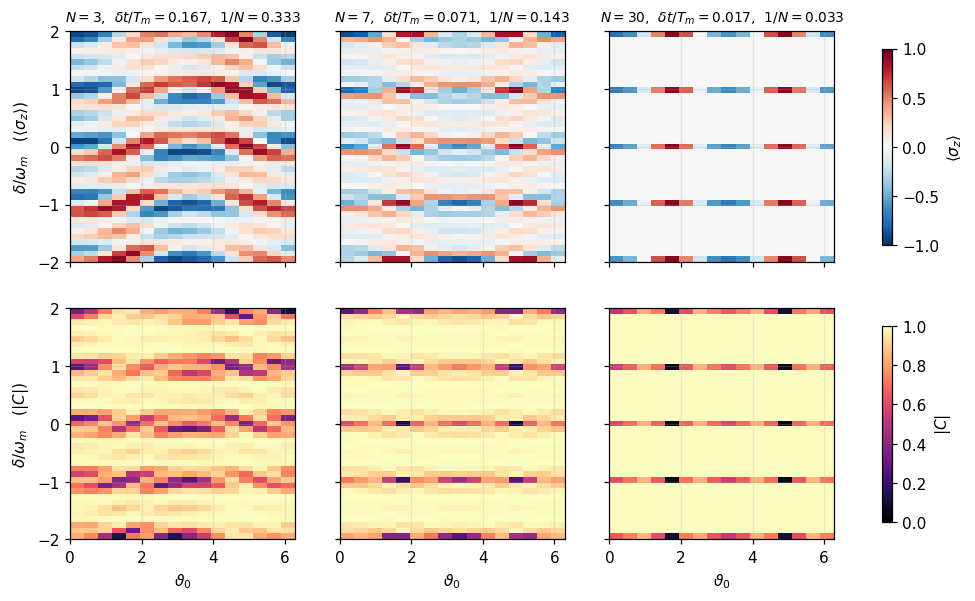

In [21]:
# Fixed Rabi rate and total rotation angle (π/2); δt scales as 1/N.
omega_eff_fixed = np.pi / T_m                         # bare rotation rate
omega_r_fixed = omega_eff_fixed / np.exp(-eta ** 2 / 2)

N_list = [3, 7, 30]
dt_list = [np.pi / (2 * omega_eff_fixed * N_j) for N_j in N_list]
maps_sz, maps_coh = [], []

t0 = time.time()
for N_j, dt_j in zip(N_list, dt_list):
    shift_deg_j = float(np.degrees(omega_m * dt_j / 2))
    psi_starts_j = []
    for th0 in theta0_grid:
        p0 = hs.prepare_state(
            spin={'theta_deg': 0.0, 'phi_deg': 0.0},
            modes=[{'alpha': alpha_abs,
                    'alpha_phase_deg': float(np.degrees(th0)) + shift_deg_j}],
        )
        psi_starts_j.append(hs.apply_mw_pi2(p0, mw_phase_deg=0.0))
    sz_j = np.zeros((N_th0, len(det_rel_grid)))
    coh_j = np.zeros_like(sz_j)
    for jdx, d_rel in enumerate(det_rel_grid):
        delta_j = d_rel * omega_m
        H_j = ham.build_pulse_hamiltonian(eta, omega_r_fixed, delta_j, nmax, C, Cdag,
                                           ac_phase_rad=0.0, omega_m=omega_m,
                                           intra_pulse_motion=True)
        Up = prop.build_U_pulse(H_j, dt_j)
        Ug = prop.build_U_gap(nmax, omega_m, T_m - dt_j, delta=delta_j)
        tr = sequences.StroboTrain(U_pulse=Up, U_gap_diag=Ug, n_pulses=N_j)
        for i, p in enumerate(psi_starts_j):
            obs = hs.observables(tr.evolve(p))
            sz_j[i, jdx] = obs['sigma_z']
            coh_j[i, jdx] = np.hypot(obs['sigma_x'], obs['sigma_y'])
    maps_sz.append(sz_j); maps_coh.append(coh_j)
print(f'  {len(N_list)} × {N_th0 * len(det_rel_grid)} evolutions in {time.time() - t0:.1f} s')

fig, axes = plt.subplots(2, 3, figsize=(11.2, 6.0), sharex=True, sharey=True)
for col, (N_j, dt_j, sz_j, coh_j) in enumerate(zip(N_list, dt_list, maps_sz, maps_coh)):
    im_sz = axes[0, col].imshow(
        sz_j.T, origin='lower',
        extent=[0, 2 * np.pi, det_rel_grid[0], det_rel_grid[-1]],
        aspect='auto', cmap='RdBu_r', vmin=-1, vmax=+1,
    )
    axes[0, col].set_title(fr'$N={N_j}$,  $\delta t/T_m={dt_j/T_m:.3f}$,  $1/N={1/N_j:.3f}$',
                            fontsize=9)
    im_coh = axes[1, col].imshow(
        coh_j.T, origin='lower',
        extent=[0, 2 * np.pi, det_rel_grid[0], det_rel_grid[-1]],
        aspect='auto', cmap='magma', vmin=0, vmax=1,
    )
    axes[1, col].set_xlabel(r'$\vartheta_0$')
axes[0, 0].set_ylabel(r'$\delta/\omega_m$   ($\langle\sigma_z\rangle$)')
axes[1, 0].set_ylabel(r'$\delta/\omega_m$   ($|C|$)')
plt.colorbar(im_sz, ax=axes[0, :].tolist(), shrink=0.85, label=r'$\langle\sigma_z\rangle$')
plt.colorbar(im_coh, ax=axes[1, :].tolist(), shrink=0.85, label=r'$|C|$')
plt.show()

## §5 Where to go next

- **Production scans** at the $\pi/2$ calibration: [`run_coh_theta0_det_v5.py`](../wp-hasse-reproduction/numerics/run_coh_theta0_det_v5.py) and the 2026-04-20 logbook.
- **Drive-strength sweeps** (Rabi envelope, single-tooth zoom, Fock-leakage audit): [2026-04-21-coh-theta0-det-rabi5x.md](../wp-hasse-reproduction/logbook/2026-04-21-coh-theta0-det-rabi5x.md), §6–§10, with the §11 consistency patch note.
- **Engine internals**: [`scripts/stroboscopic/`](../scripts/stroboscopic) — `HilbertSpace`, `build_pulse_hamiltonian`, `build_U_pulse`, `build_U_gap`, `StroboTrain`.

Physical parameters used throughout this notebook ($|\alpha|=3$, $\eta=0.397$, $\omega_m=1.3$, $N=30$, $\delta t/T_m = 0.13$) are chosen close enough to the Hasse reference that the ${(\vartheta_0, \delta)}$ slice above is qualitatively the same map visitors will see in the logbook figures.
